# Experiment 2

Idea: Incorporate fairness into the reward

In [ ]:
import copy

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from stable_baselines3.ppo import PPO

from config import (
    CALENDAR_SEED,
    DEMAND_MODEL_PRICE_GRANULARITY,
    ENV_SEED,
    N_SNAP_DAYS,
    NOISE_RANGE,
    NUM_PRODUCTS,
    NUM_TIMESTEPS,
    P_DIFF,
    P_MAX,
    P_MIN,
    PPO_HYPERPARAMS,
    PPO_WARMUP_NR_EPISODES,
    K,
    FAIRNESS_WEIGHTS_LIST,
)
from fair_dynamic_pricing_with_rl.utils.demand_model import DemandModelEstimator
from fair_dynamic_pricing_with_rl.utils.env import FMCGEnv
from fair_dynamic_pricing_with_rl.utils.fairness_utils import compute_jains_index


In [2]:
unit_sales = pd.read_csv("../data/sales_train_evaluation.csv")
prices = pd.read_csv("../data/sell_prices.csv")
calendar = pd.read_csv("../data/calendar.csv")

In [ ]:
demand_model_estimator = DemandModelEstimator(
    unit_sales_df = unit_sales,
    prices_df = prices,
    calendar_df = calendar,
    price_granularity = DEMAND_MODEL_PRICE_GRANULARITY,
    verbose = False # demand parameters were shown in experiment 1
)

demand_model_parameters = demand_model_estimator.run_pipeline()

## New environment with modified objective, including Jain's index.

In [ ]:
class FMCGEnv2(FMCGEnv):
    def __init__(
        self,
        p_min: np.ndarray,
        p_max: np.ndarray,
        p_diff: np.ndarray,
        betas: list,
        noise_range: int,
        max_demand: int,
        n_snap_days: int,
        calendar_seed=None,
        T: int = 365,
        rew_weights=None,
    ):
        """Initialize FMCG Gymnasium environment.

        Args:
            p_min (np.array): minimum price vector of products (L)
            p_max (np.array): maximum price vector of products (L)
            p_diff (np.array): price step vector of products (L)
            betas (List[np.ndarray]): demand core state param. for non-SNAP and SNAP households
            noise_range (int): maximum value of noise (symmetric)
            max_demand (int): the maximum daily demand considering all L products
            n_snap_days (int): number of SNAP days in a 30-day month.
            calendar_seed (int, optional): seed used for constructing SNAP calendar
            T (int, optional): length of episode (defaults to 365),
            rew_weights (np.ndarray): reward weights for profits vs. fairness tradeoff (default: 50-50%)
        """
        super().__init__(p_min, p_max,p_diff,
                         betas, noise_range, max_demand, n_snap_days, calendar_seed,
                         T)
        if rew_weights is None:
            self.rew_weights = np.array([0.5,0.5])
        else:
            self.rew_weights = rew_weights

    def _get_reward(self,
                    p: np.ndarray,
                    d: np.ndarray,
                    ):
        """ Returns reward, weighted avg. of revenue and Jain's index
        Args:
            p (np.ndarray): price vector (L)
            d (np.ndarray): demand vector (L)

        Returns:
            reward (float): reward from taking action p at the given state
        """
        revenue = p @ d

        # groups are esentially the sensitive attribute mask with length t
        mask_t = np.resize(self.mask, self._t)

        jains_index, _ = compute_jains_index(action_hist=self.action_history,
                                          groups=mask_t,
                                          p_min=self.p_min,
                                          p_diff=self.p_diff)

        # weight the components of the reward
        reward = np.dot(np.array([revenue,jains_index]), self.rew_weights)
        return reward

In [5]:
# Register the environment so we can create it with gym.make()
gym.register(
    id="gymnasium_env/FMCGEnv2",
    entry_point=FMCGEnv2,
    max_episode_steps=500,  # Prevent infinite episodes
)

In [6]:
def running_model(env1,
                  alg,
                  T,
                  K,
                  num_products,
                  seed=None
                  ):
    """ Running PPO algorithm

    Args:
        env1 (FMCGEnv2): the defined gym environment
        alg (stable_baselines3.PPO): PPO policy
        T (int): number of timesteps per episode
        K (int): number of episodes
        num_products (int): number of products
        seed (int): seed for reproducibility

    Returns:
        rew (np.ndarray): rewards (T,K)
        action_hist (np.ndarray): action history (T,K,L)
        groups (np.ndarray): groups according to binary sensitive attribute (T,K)
    """

    env = copy.deepcopy(env1)

    rew = np.zeros((T,K))
    action_hist = np.zeros((T,K,num_products))
    groups = np.zeros((T,K))

    for k in range(K):
        # sample initial state
        # seed each reset deterministically but distinctly per episode
        observation, info = env.reset(seed=None if seed is None else seed + k)

        for t in range(T):
            # save the group wrt. sensitive attribute
            groups[t,k] = observation['sensitive_attr']
            
            # take action using trained model
            action, _states = alg.predict(observation, deterministic=True)
            a = np.asarray(action)
            
            action_hist[t,k] = a

            # record new state/reward from action played
            observation, reward, terminated, truncated, info = env.step(a)

            rew[t,k] = reward
        
    return rew, action_hist, groups

In [ ]:
# storing expected mean episode rewards
episode_rewards_comparison = np.zeros((K*len(FAIRNESS_WEIGHTS_LIST),3))
# storing Jain's indexes and mean episode revenues
results = pd.DataFrame(np.zeros((len(FAIRNESS_WEIGHTS_LIST),5)),
                       columns=["mean_episode_revenue","jains_index","random_action_prob", "nonsnap_price", "snap_price"])

for idx in range(len(FAIRNESS_WEIGHTS_LIST)):

    # make environment with chosen revenue - fairness weights
    fair_w = FAIRNESS_WEIGHTS_LIST[idx]
    env = gym.make("gymnasium_env/FMCGEnv2",
               p_min=P_MIN,
               p_max=P_MAX,
               p_diff=P_DIFF,
               betas=[params.to_numpy() for params in demand_model_parameters[3]],
               max_demand=demand_model_parameters[4],
               n_snap_days=N_SNAP_DAYS,
               calendar_seed=CALENDAR_SEED,
               noise_range=NOISE_RANGE,
               rew_weights=np.array([1-fair_w, fair_w])
               )

    # define and warm-up algorithm
    # PPO hyperparameters from Liu et al. (2024)
    model = PPO(policy="MultiInputPolicy",
                env=env,
                learning_rate=PPO_HYPERPARAMS["learning_rate"],
                batch_size=PPO_HYPERPARAMS["batch_size"], # default
                clip_range=PPO_HYPERPARAMS["clip_range"], # default
                seed=PPO_HYPERPARAMS["seed"])

    model.learn(total_timesteps=PPO_WARMUP_NR_EPISODES,
                progress_bar=True)

    rewards, action_hist, groups = running_model(env1=env,
                                             alg=model,
                                             T=NUM_TIMESTEPS,
                                             K=K,
                                             num_products=NUM_PRODUCTS,
                                             seed=ENV_SEED)
 
    episode_rewards = rewards.sum(axis=0)
    e_mean_episode_reward = episode_rewards.cumsum() / (np.arange(K) + 1)

    # expected mean episode rewards
    episode_rewards_comparison[(idx*K):((idx+1)*K),0] = np.arange(K)
    episode_rewards_comparison[(idx*K):((idx+1)*K),1] = e_mean_episode_reward

    # random action probability
    episode_rewards_comparison[(idx*K):((idx+1)*K),2] = FAIRNESS_WEIGHTS_LIST[idx]

    # save main performance metrics
    results.loc[idx,"fairness_weight"] = FAIRNESS_WEIGHTS_LIST[idx]
    results.loc[idx,"mean_episode_revenue"] = episode_rewards.mean()
    results.loc[idx, "jains_index"], group_values = compute_jains_index(action_hist,
                                                                        groups,
                                                                        p_min=P_MIN,
                                                                        p_diff=P_DIFF)
    results.loc[idx, "nonsnap_price"] = group_values[False]
    results.loc[idx, "snap_price"] = group_values[True]    

c:\Users\Kim Levente\AppData\Local\Programs\Python\Python313\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\Kim Levente\AppData\Local\Programs\Python\Python313\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\Kim Levente\AppData\Local\Programs\Python\Python313\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\Kim Levente\AppData\Local\Programs\Python\Python313\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [ ]:
results

,mean_episode_revenue,jains_index,fairness_weight
0,59.944769,1.0,1.0
1,2489.183229,1.0,0.7
2,4107.370842,1.0,0.5
3,8153.050413,1.0,0.0


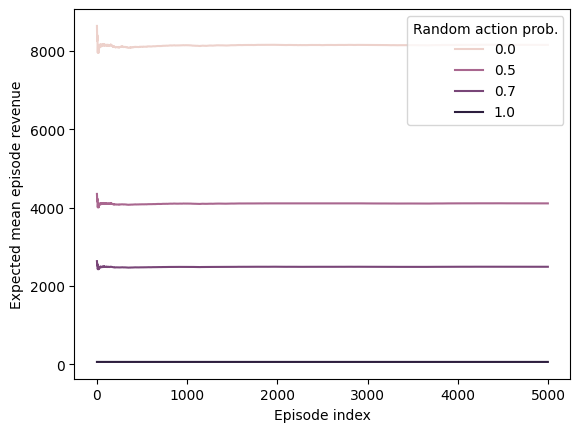

In [ ]:
episode_rewards_comparison_df = pd.DataFrame(episode_rewards_comparison,
                                             columns=["episode_idx", "mean_episode_revenue", "fairness_weight"])

# for plotting every episode ex. first x: data = episode_rewards_comparison_df.loc[episode_rewards_comparison_df.episode_idx > 50.0],
sns.lineplot(data = episode_rewards_comparison_df,
             x="episode_idx",
             y="mean_episode_revenue",
             hue="fairness_weight")
plt.xlabel("Episode index")
plt.ylabel("Expected mean episode revenue")
plt.legend(title="Fairness weight")
plt.show()

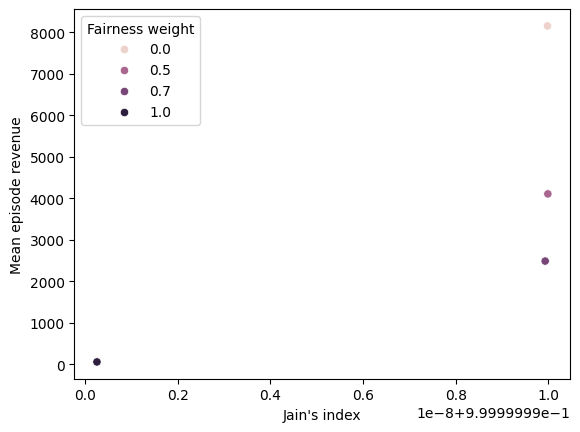

In [ ]:
sns.scatterplot(data=results, x="jains_index", y="mean_episode_revenue",
                hue="fairness_weight")
plt.xlabel("Jain's index")
plt.ylabel("Mean episode revenue")
plt.legend(title="Fairness weight")
plt.show()